In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [21]:
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

df.head()


Saving heart.csv to heart (1).csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [22]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)


Before: (1025, 14)
After: (302, 14)


In [23]:
X = df.drop('target', axis=1)
y = df['target']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [25]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7704918032786885


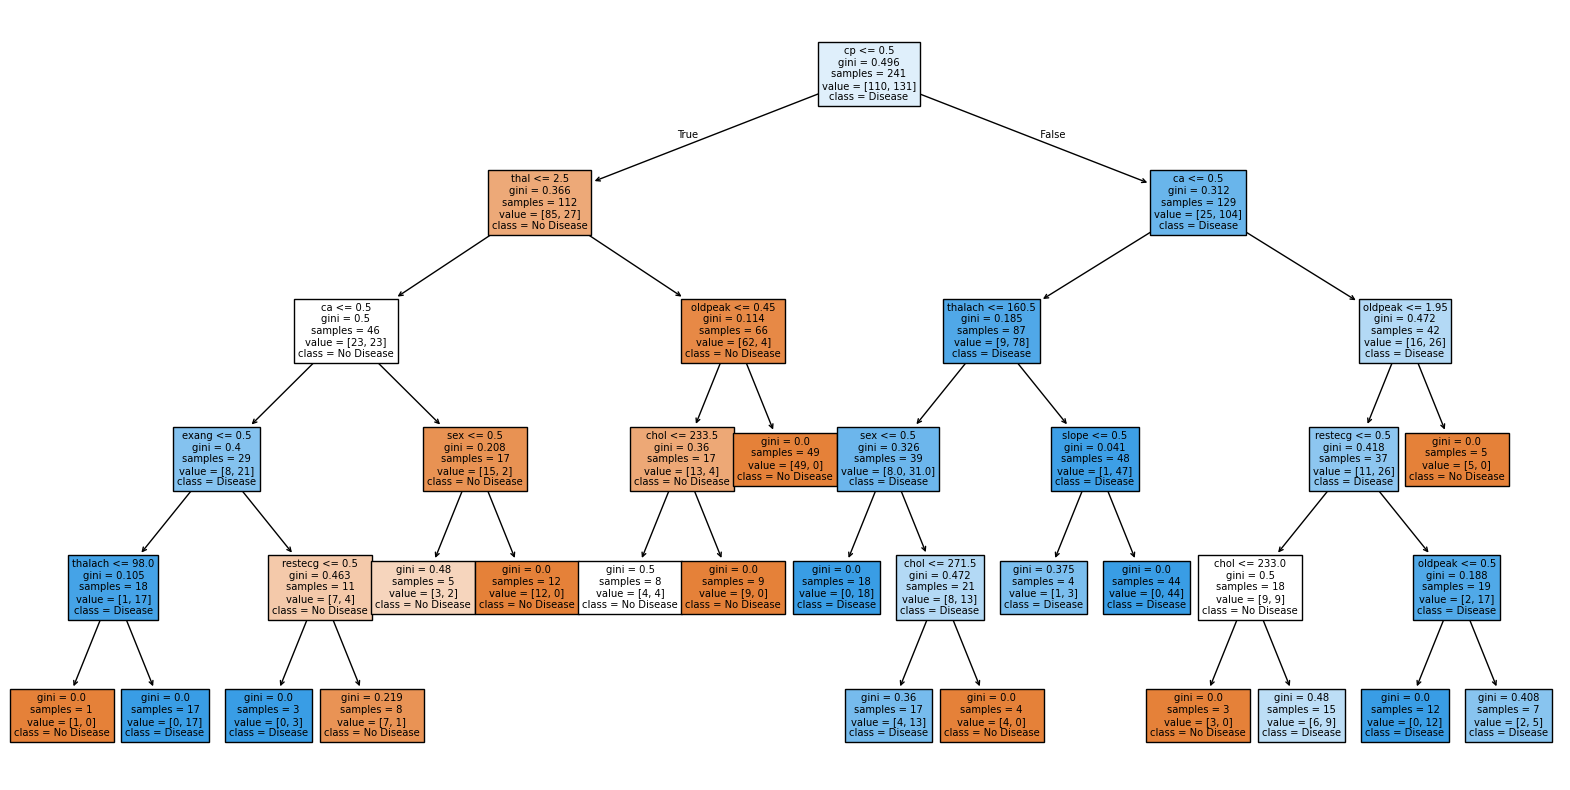

In [26]:
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=['No Disease','Disease'], filled=True)
plt.show()


In [27]:
dt_pruned = DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)

print("Pruned Tree Accuracy:", accuracy_score(y_test, y_pred_pruned))


Pruned Tree Accuracy: 0.8032786885245902


In [28]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.7704918032786885


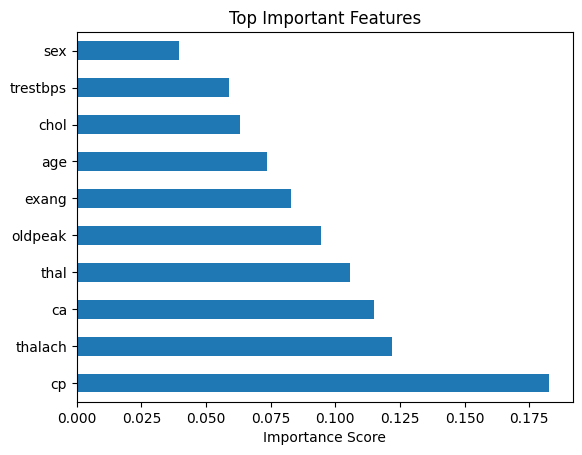

In [32]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)[:10].plot(kind='barh')

plt.title("Top Important Features")
plt.xlabel("Importance Score")
plt.show()



In [30]:
scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Accuracy:", scores.mean())


Cross Validation Scores: [0.86885246 0.83606557 0.88333333 0.8        0.75      ]
Average CV Accuracy: 0.8276502732240438


Conclusion

In this task, Decision Tree and Random Forest classifiers were implemented to predict the presence of heart disease. The dataset was cleaned by removing duplicate records and split using stratified sampling to ensure balanced training and testing data.

The initial decision tree showed moderate accuracy but suffered from overfitting. After applying pruning by limiting the tree depth, the model generalized better and achieved improved performance. The Random Forest model produced similar accuracy due to the small dataset size, demonstrating that ensemble models require sufficient data diversity to outperform single models.

Overall, the experiment shows that controlling model complexity is important for tree-based algorithms. A properly pruned decision tree can sometimes perform as well as or better than more complex models on smaller datasets.